In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import statsmodels.api as sm

In [144]:
file_path_monthly = '/Users/landieraugustin/Dropbox/datascience2024/Sourcedata/stocks_monthly.csv'
file_path_daily = '/Users/landieraugustin/Dropbox/datascience2024/Sourcedata/stocks_daily.csv'
file_path_factors = '/Users/landieraugustin/Dropbox/datascience2024/Sourcedata/FF_factors.csv'

In [145]:
# Load three datasets:
# - df_m (monthly): used for universe construction (has market cap, share codes)
# - df_d (daily): used for return calculations and backtesting
# - df_factor: Fama-French factors (market, size, value, momentum) for performance attribution
# PERMNO is the unique stock identifier from CRSP database

df_factor = pd.read_csv(file_path_factors)
df_m = pd.read_csv(file_path_monthly)
df_d = pd.read_csv(file_path_daily)
df_d.drop_duplicates(inplace=True)

df_d['date'] = pd.to_datetime(df_d['date'])
df_m['date'] = pd.to_datetime(df_m['date'])
df_factor['date'] = pd.to_datetime(df_factor['date'])

df_d['year'] = df_d['date'].dt.year
df_m['year'] = df_m['date'].dt.year
df_d.head()

/var/folders/jw/k_60pp0j7bd8b4z1bn524qsc0000gn/T/ipykernel_20760/1354128721.py:8: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  df_m = pd.read_csv(file_path_monthly)
/var/folders/jw/k_60pp0j7bd8b4z1bn524qsc0000gn/T/ipykernel_20760/1354128721.py:9: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df_d = pd.read_csv(file_path_daily)


,PERMNO,date,RET,sprtrn,year
0,10001,1994-01-03,-0.034014,-0.002165,1994
1,10001,1994-01-04,-0.014085,0.003115,1994
2,10001,1994-01-05,0.028571,0.001414,1994
3,10001,1994-01-06,-0.041667,-0.000920,1994
4,10001,1994-01-07,0.036232,0.005951,1994


# 1. DEFINE A TRADING UNIVERSE: LIQUID U.S. STOCKS

In [146]:
# DEFINING A TRADING UNIVERSE: Why it matters
# 
# A proper backtest requires a point-in-time (PIT) universe to avoid LOOK-AHEAD BIAS:
# we can only trade stocks that were known to be liquid AT THAT TIME.
#
# We select the top 1500 stocks by market cap, using ONLY past information:
# - Market cap from previous December determines eligibility for the next year
# - This mimics how a real trader would construct their universe

In [147]:
# STOCK FILTERING: Keep only tradable U.S. equities
#
# SHRCD 10,11 = ordinary common shares (excludes ADRs, REITs, closed-end funds, etc.)
df_m = df_m[(df_m['SHRCD'] == 10) | (df_m['SHRCD'] == 11)]

# EXCHCD 1,2,3 = NYSE, AMEX, NASDAQ (excludes OTC markets with poor liquidity)
df_m = df_m[(df_m['EXCHCD'] == 1) | (df_m['EXCHCD'] == 2) | (df_m['EXCHCD'] == 3)]

# Exclude penny stocks (price < $5): they have wide bid-ask spreads, 
# are prone to manipulation, and are often untradable at scale
df_m['lagged_price'] = df_m.groupby('PERMNO')['PRC'].shift(1)
df_m = df_m[df_m['lagged_price'] >= 5].reset_index()

df_m = df_m.drop_duplicates(subset=['PERMNO', 'date'], keep='first')

In [148]:
df_m.head()

,index,PERMNO,date,SHRCD,EXCHCD,SICCD,TICKER,SHRCLS,PRIMEXCH,TRDSTAT,DIVAMT,PRC,VOL,RET,SHROUT,ewretx,sprtrn,year,lagged_price
0,4,10001,1994-04-29,11.0,3.0,4920.0,EWST,NaN,Q,A,NaN,14.750,102.0,-0.144928,1091.0,-0.012827,0.011531,1994,17.25
1,5,10001,1994-05-31,11.0,3.0,4920.0,EWST,NaN,Q,A,NaN,15.750,146.0,0.067797,1091.0,-0.002287,0.012419,1994,14.75
2,6,10001,1994-06-30,11.0,3.0,4920.0,EWST,NaN,Q,A,0.190,-8.625,234.0,0.107302,2191.0,-0.029647,-0.026812,1994,15.75
3,9,10001,1994-08-31,11.0,3.0,4920.0,EWST,NaN,Q,A,NaN,9.000,159.0,-0.027027,2191.0,0.035159,0.037643,1994,9.25
4,10,10001,1994-09-30,11.0,3.0,4920.0,EWST,NaN,Q,A,0.095,9.250,121.0,0.038333,2211.0,0.003459,-0.026898,1994,9.00


In [149]:
# BUILD SIZE-BASED UNIVERSE: Top 2500 stocks by market cap
#
# KEY POINT: We use LAGGED market cap (from previous December) to avoid look-ahead bias.
# At each point in time t, we only know market caps from t-1 or earlier.

# Market cap = shares outstanding * price
df_m['market_cap'] = df_m['PRC'].abs() * df_m['SHROUT']

# Get year-end market cap for each stock
df_m['year_end'] = df_m.groupby(['PERMNO', 'year'])['date'].transform('max')
df_end_of_year = df_m.drop_duplicates(subset=['PERMNO', 'year_end']).copy()

# Shift forward by 1 year: December 2020 market cap determines 2021 eligibility
df_end_of_year['year'] += 1

# Merge lagged market cap onto daily data
df_merged = df_d.merge(
    df_end_of_year[['PERMNO', 'year', 'market_cap', 'SICCD', 'VOL', 'SHROUT']],
    on=['PERMNO', 'year'],
    how='left',
    suffixes=('', '_prev_year')
)

# Rank stocks by market cap within each date (largest = rank 1)
df_merged = df_merged.sort_values(by=['date', 'market_cap'], ascending=[True, False])
df_merged['rank'] = np.where(df_merged['market_cap'].isna(), np.nan, 
                              df_merged.groupby('date')['market_cap'].cumcount() + 1)

# Keep top 2500 for our universe
ranked_stocks = df_merged[df_merged['rank'] <= 2500]
ranked_stocks.reset_index(drop=True, inplace=True)

# 2. MOMENTUM PORTFOLIO

## Step 1: Calculate Cumulative Returns

In [150]:
# MOMENTUM SIGNAL CALCULATION
#
# The Momentum Anomaly (Jegadeesh & Titman, 1993):
# Stocks that performed well over the past 12 months tend to continue outperforming.
# This is one of the most robust anomalies in finance.
#
# Standard momentum window: months t-12 to t-2 (skip the most recent month)
# - Skip recent month: short-term REVERSAL contaminates the signal
# - Use ~12 months: captures medium-term price trends
#
# In daily terms: days -252 to -21 (approximately 12 months, skip last month)

df = ranked_stocks.copy().reset_index(drop=True)
df['RET'] = pd.to_numeric(df['RET'], errors='coerce')
df.dropna(subset=['RET'], inplace=True)

df['date'] = pd.to_datetime(df['date'])
df = df.reset_index(drop=True)
df['RET'] = df['RET'].astype(float)
df.sort_values(by=['PERMNO', 'date'], inplace=True)

# Momentum = cumulative return from t-252 to t-21 (sum of log returns approximates this)
# window=231 days, shifted by 21 days
df['momentum'] = df.groupby('PERMNO')['RET'].transform(
    lambda x: x.rolling(window=231, min_periods=115).sum().shift(21)
)

In [151]:
df

,PERMNO,date,RET,sprtrn,year,market_cap,SICCD,VOL,SHROUT,rank,momentum
7528070,10002,2006-12-15,-0.024343,0.001122,2006,2.352984e+05,6020.0,3872.0,11021.0,2500.0,NaN
7530564,10002,2006-12-18,-0.028911,-0.003230,2006,2.352984e+05,6020.0,3872.0,11021.0,2499.0,NaN
7533059,10002,2006-12-19,0.010604,0.002158,2006,2.352984e+05,6020.0,3872.0,11021.0,2499.0,NaN
7535552,10002,2006-12-20,0.006053,-0.001417,2006,2.352984e+05,6020.0,3872.0,11021.0,2499.0,NaN
7538043,10002,2006-12-21,0.014842,-0.003674,2006,2.352984e+05,6020.0,3872.0,11021.0,2498.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...
18219415,93436,2023-12-22,-0.007701,0.001660,2023,9.681076e+08,9999.0,6361641.0,1033508.0,4.0,0.686905
18221915,93436,2023-12-26,0.016116,0.004232,2023,9.681076e+08,9999.0,6361641.0,1033508.0,4.0,0.781027
18224414,93436,2023-12-27,0.018822,0.001430,2023,9.681076e+08,9999.0,6361641.0,1033508.0,4.0,0.801254
18226912,93436,2023-12-28,-0.031594,0.000370,2023,9.681076e+08,9999.0,6361641.0,1033508.0,4.0,0.960412


## Step 2: Long-short returns based on Momentum sorting

In [152]:
# LONG-SHORT PORTFOLIO CONSTRUCTION
#
# A long-short portfolio is MARKET NEUTRAL: we buy winners and sell losers.
# The net investment is zero, so returns come purely from the spread between winners and losers.
#
# Approach: 
# - Rank all stocks by momentum each day
# - Go LONG the top decile (highest momentum)
# - Go SHORT the bottom decile (lowest momentum)
# - Equal-weight within each leg for simplicity

In [ ]:
def calculate_ls_returns(df, sorting_variable, threshold, Nstocks):
    """
    Construct a long-short portfolio based on percentile ranks of a sorting variable.
    
    Parameters:
    - df: DataFrame with columns ['date', 'PERMNO', 'RET', 'rank', sorting_variable]
    - sorting_variable: Column name to sort stocks on (e.g., 'momentum')
    - threshold: Percentile cutoff (0.1 = top/bottom 10%, 0.3 = top/bottom 30%)
    - Nstocks: Universe size (e.g., 1500 = largest 1500 stocks)
    
    Returns:
    - DataFrame with daily long-short returns and turnover (as % of nominal)
    
    Convention: Nominal = 2 (100% long + 100% short), like Fama-French factors.
    Turnover is expressed as a fraction of total nominal.
    """
    strategy_df = df.copy()
    
    # Restrict to top N stocks by market cap
    strategy_df = strategy_df[strategy_df['rank'] <= Nstocks]
    strategy_df.dropna(subset=[sorting_variable], inplace=True)

    # Rank stocks by signal within each day (pct_rank: 0=lowest, 1=highest)
    strategy_df['pct_rank'] = strategy_df.groupby('date')[sorting_variable].rank(
        method='first', ascending=True, pct=True
    )

    # Assign positions: +1 for top percentile (long), -1 for bottom (short)
    strategy_df['position'] = 0
    strategy_df.loc[strategy_df['pct_rank'] > 1-threshold, 'position'] = 1   # Long winners
    strategy_df.loc[strategy_df['pct_rank'] <= threshold, 'position'] = -1   # Short losers
    
    # Compute weights (equal-weight within each leg)
    # Nominal = 2: long leg sums to +1, short leg sums to -1
    strategy_df['n_long'] = strategy_df.groupby('date')['position'].transform(
        lambda x: (x == 1).sum()
    )
    strategy_df['n_short'] = strategy_df.groupby('date')['position'].transform(
        lambda x: (x == -1).sum()
    )
    
    strategy_df['weight'] = 0.0
    strategy_df.loc[strategy_df['position'] == 1, 'weight'] = (
        1.0 / strategy_df.loc[strategy_df['position'] == 1, 'n_long']
    )
    strategy_df.loc[strategy_df['position'] == -1, 'weight'] = (
        -1.0 / strategy_df.loc[strategy_df['position'] == -1, 'n_short']
    )
    
    # Calculate daily long-short return
    strategy_df['weighted_ret'] = strategy_df['weight'] * strategy_df['RET']
    daily_return = strategy_df.groupby('date')['weighted_ret'].sum()
    
    # Calculate turnover: sum of |weight_t - weight_{t-1}| / nominal
    # Divided by 2 to express as % of total nominal
    strategy_df = strategy_df.sort_values(['PERMNO', 'date'])
    strategy_df['weight_change'] = strategy_df.groupby('PERMNO')['weight'].diff().abs()
    daily_turnover = strategy_df.groupby('date')['weight_change'].sum() / 2
    
    result = pd.DataFrame({
        'LS_return': daily_return,
        'turnover': daily_turnover
    })
    
    return result

In [154]:
strategy=calculate_ls_returns(df, 'momentum', 0.3, 1500)

In [155]:
strategy

,LS_return
date,
1994-07-18,-0.039343
1994-07-19,0.017474
1994-07-20,-0.009795
1994-07-21,0.017878
1994-07-22,0.005587
...,...
2023-12-22,-0.001265
2023-12-26,-0.002068
2023-12-27,0.001413


## Step 3: Graph cumulative returns of the baseline strategy

In [156]:
# PERFORMANCE ANALYSIS: Sharpe Ratio and Factor Regression
#
# Two key metrics for evaluating a trading strategy:
#
# 1. SHARPE RATIO = (mean return) / (std of returns) * sqrt(252)
#    - Measures risk-adjusted performance
#    - Annualized by multiplying by sqrt(252) for daily data
#    - SR > 1 is generally considered good; SR > 2 is excellent
#
# 2. FACTOR REGRESSION (Fama-French + Momentum)
#    - Decomposes returns into factor exposures and alpha
#    - mktrf: market excess return (beta exposure)
#    - smb: small minus big (size exposure)
#    - hml: high minus low (value exposure)
#    - umd: up minus down (momentum factor)
#    - const (alpha): return unexplained by factors

In [ ]:
def analyze_cumulative_returns(strategy_df, column_name='LS_return'):
    """
    Analyze strategy performance: plot cumulative returns and run factor regression.
    
    The function:
    1. Plots cumulative returns over time
    2. Computes and displays the annualized Sharpe ratio (and turnover if available)
    3. Regresses returns on Fama-French factors to decompose performance
    """
    # Cumulative returns (sum of daily returns approximates log growth)
    cumulative_returns = strategy_df[column_name].cumsum()
    
    # Sharpe ratio: annualized by multiplying daily SR by sqrt(252)
    excess_returns = strategy_df[column_name] 
    daily_sharpe_ratio = excess_returns.mean() / excess_returns.std()
    annualized_sharpe_ratio = daily_sharpe_ratio * (252**0.5)
    
    # Plot cumulative returns
    plt.figure(figsize=(10, 6))
    plt.plot(cumulative_returns.index, cumulative_returns.values, label='Cumulative Returns')
    plt.gca().xaxis.set_major_locator(mdates.YearLocator())
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    plt.gcf().autofmt_xdate()
    plt.xlabel('Date')
    plt.ylabel('Cumulative Return')
    plt.title('Cumulative Returns Over Time')
    
    # Build stats text (Sharpe + optionally Turnover)
    stats_text = f'Sharpe Ratio: {annualized_sharpe_ratio:.2f}'
    
    # Use matching turnover column if available
    if column_name == 'LS_return_volcontrol' and 'turnover_volcontrol' in strategy_df.columns:
        avg_turnover = strategy_df['turnover_volcontrol'].mean()
        stats_text += f'\nAvg Daily Turnover: {avg_turnover:.1%}'
    elif 'turnover' in strategy_df.columns:
        avg_turnover = strategy_df['turnover'].mean()
        stats_text += f'\nAvg Daily Turnover: {avg_turnover:.1%}'
    
    plt.text(0.5, 0.1, stats_text, 
             transform=plt.gca().transAxes, fontsize=9, 
             bbox=dict(facecolor='white', alpha=0.5))
    plt.legend(loc='upper right', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.legend()
    plt.show()

    # Factor regression: decompose returns into systematic exposures + alpha
    merged_df = pd.merge(df_factor, strategy_df, on='date', how='inner')
    merged_df = merged_df.dropna(subset=[column_name]) 
    X = merged_df[['mktrf', 'smb', 'hml', 'umd']]
    y = merged_df[column_name]
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    print(model.summary())

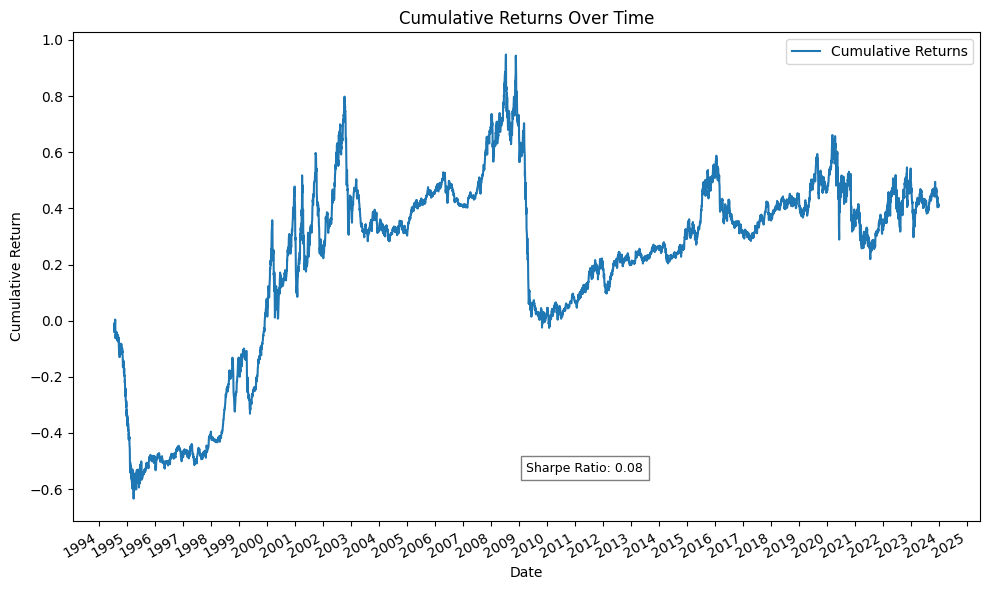

                            OLS Regression Results                            
Dep. Variable:              LS_return   R-squared:                       0.800
Model:                            OLS   Adj. R-squared:                  0.799
Method:                 Least Squares   F-statistic:                     7391.
Date:                Mon, 02 Feb 2026   Prob (F-statistic):               0.00
Time:                        19:06:05   Log-Likelihood:                 29071.
No. Observations:                7417   AIC:                        -5.813e+04
Df Residuals:                    7412   BIC:                        -5.810e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0001   5.58e-05     -2.571      0.0

In [158]:
analyze_cumulative_returns(strategy_df=strategy, column_name='LS_return')

# 3. IDEAS TO IMPROVE THE STRATEGY

The baseline momentum strategy can be enhanced in several ways. Below we explore techniques commonly used by quant practitioners.

## Idea 1: Volatility Targeting (Dynamic Leverage)

**Intuition:** Reduce exposure during volatile periods, increase during calm periods.

This is a form of RISK PARITY: instead of targeting constant dollar exposure, we target constant risk exposure. When volatility spikes (e.g., during a crisis), we automatically de-lever, reducing drawdowns.

In [159]:
# Leverage = inverse of recent volatility
# High recent volatility -> low leverage (protect capital)
# Low recent volatility -> high leverage (exploit calm markets)

In [160]:
# Calculate leverage as inverse of 20-day rolling volatility
# shift(1) ensures we only use past information (no look-ahead bias)
strategy['leverage'] = (1 / strategy['LS_return'].rolling(window=20).std()).shift(1)

# Normalize leverage to have mean=1 over the sample
# NOTE: This normalization uses full-sample info (slight look-ahead bias for interpretability)
strategy['leverage'] = strategy['leverage'] / strategy['leverage'].mean()

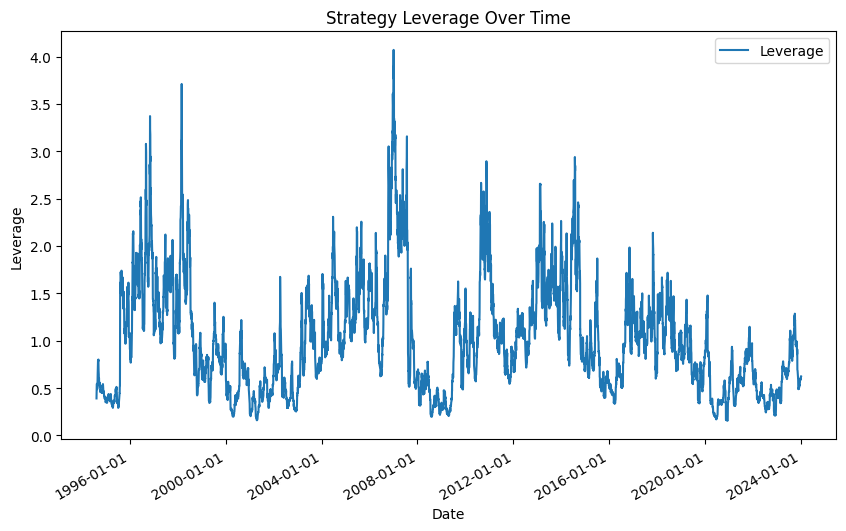

In [161]:
# Now we can plot leverage over time to get a sense of how much it varies
plt.figure(figsize=(10, 6))
plt.plot(strategy.dropna(subset=['leverage']).index, strategy['leverage'].dropna(), label='Leverage')

# Format the x-axis to show dates with a specific format, e.g., year-month-day.
plt.gca().xaxis.set_major_locator(mdates.AutoDateLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

# Rotate the x-axis labels for better readability.
plt.gcf().autofmt_xdate()

# Add labels and title.
plt.xlabel('Date')
plt.ylabel('Leverage')
plt.title('Strategy Leverage Over Time')

# Show the plot with a legend.
plt.legend()
plt.show()

In [ ]:
# Apply volatility control
strategy['LS_return_volcontrol'] = strategy['leverage'] * strategy['LS_return']

# Turnover for vol-controlled strategy (as % of nominal):
# = leverage × base_turnover (rebalancing scales with position size)
# + |Δleverage| (trading to adjust total exposure)
strategy['turnover_volcontrol'] = (
    strategy['leverage'] * strategy['turnover'] + 
    strategy['leverage'].diff().abs()
)

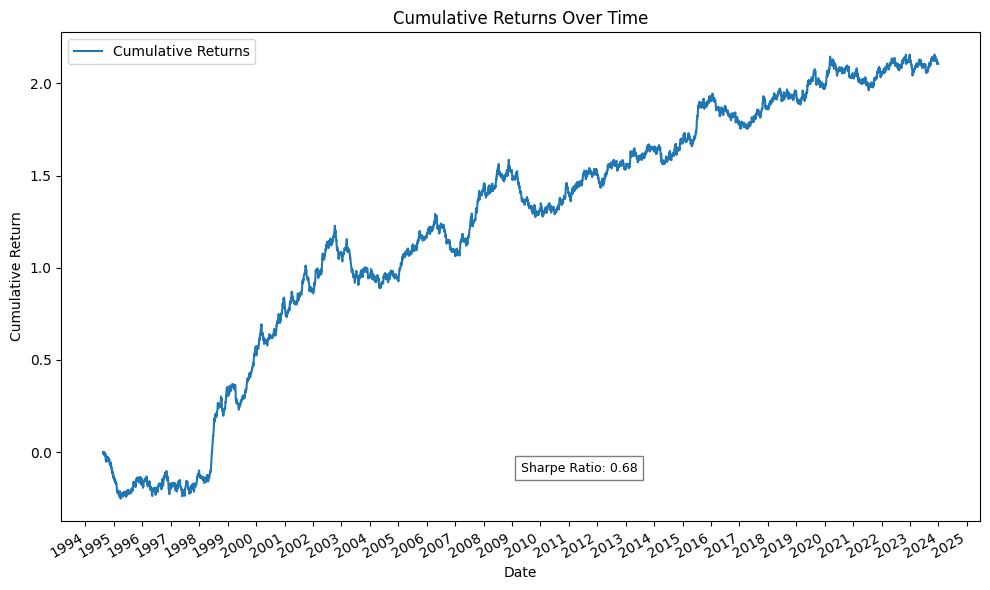

                             OLS Regression Results                             
Dep. Variable:     LS_return_volcontrol   R-squared:                       0.584
Model:                              OLS   Adj. R-squared:                  0.583
Method:                   Least Squares   F-statistic:                     2591.
Date:                  Mon, 02 Feb 2026   Prob (F-statistic):               0.00
Time:                          19:06:06   Log-Likelihood:                 29795.
No. Observations:                  7397   AIC:                        -5.958e+04
Df Residuals:                      7392   BIC:                        -5.955e+04
Df Model:                             4                                         
Covariance Type:              nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0001   5.02e-05

In [163]:
analyze_cumulative_returns(strategy_df=strategy, column_name='LS_return_volcontrol')

In [164]:
# Volatility targeting improves the Sharpe ratio. Let's embed it into our strategy function.

In [ ]:
def calculate_ls_returns_v2(df, sorting_variable, threshold, Nstocks, ndays):
    """
    Enhanced long-short strategy with volatility targeting.
    
    Adds dynamic leverage based on rolling volatility:
    leverage = 1 / rolling_std, normalized to have unit standard deviation.
    
    Turnover is adjusted for leverage changes (as % of nominal):
    turnover = leverage × base_turnover + |Δleverage|
    
    Convention: Nominal = 2 (like Fama-French factors).
    """
    LS = calculate_ls_returns(df, sorting_variable, threshold, Nstocks)
    
    # Dynamic leverage: inverse of recent volatility
    LS['leverage'] = (1 / LS['LS_return'].rolling(window=ndays).std()).shift(1)
    LS['leverage'] = LS['leverage'] / LS['leverage'].std()
    
    # Adjust turnover for leverage (all expressed as % of nominal)
    LS['turnover'] = LS['leverage'] * LS['turnover'] + LS['leverage'].diff().abs()
    
    # Apply leverage to returns
    LS['LS_return'] = LS['leverage'] * LS['LS_return']
    
    return LS[['LS_return', 'turnover']]

## Idea 2: Beta-Adjusted Momentum (Removing Market Exposure)

**Problem:** Momentum often picks up high-beta stocks in the long leg and low-beta stocks in the short leg.
This creates unintended market exposure: momentum profits partly reflect market timing, not stock selection.

**Solution:** Define momentum on BETA-ADJUSTED RETURNS (idiosyncratic returns):
- adjusted_return = return - beta * market_return
- This isolates stock-specific performance from market movements

In [166]:
# Merge with Fama-French factors to get risk-free rate
df = pd.merge(df_factor, df, on='date', how='inner')

# Convert returns to EXCESS returns (subtract risk-free rate)
df['RET'] = df['RET'] - df['rf']
df['sprtrn'] = df['sprtrn'] - df['rf']

# Calculate ROLLING BETA for each stock
# Beta = Cov(stock, market) / Var(market)
# Using 120-day rolling window
df['rolling_covariance'] = df.groupby('PERMNO').apply(
    lambda x: x['RET'].rolling(window=120, min_periods=60).cov(x['sprtrn'])
).reset_index(level=0, drop=True)

df['rolling_variance'] = df.groupby('PERMNO')['sprtrn'].rolling(
    window=120, min_periods=60
).var().reset_index(level=0, drop=True)

df['rolling_beta'] = df['rolling_covariance'] / df['rolling_variance']

# BETA-ADJUSTED RETURN = Total return - Beta * Market return
# This is the stock's "idiosyncratic" or "residual" return
df['adjusted_RET'] = df['RET'] - df['rolling_beta'] * df['sprtrn']

/var/folders/jw/k_60pp0j7bd8b4z1bn524qsc0000gn/T/ipykernel_20760/3381333437.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df['rolling_covariance'] = df.groupby('PERMNO').apply(


In [167]:
df

,date,mktrf,smb,hml,rf,umd,PERMNO,RET,sprtrn,year,market_cap,SICCD,VOL,SHROUT,rank,momentum,rolling_covariance,rolling_variance,rolling_beta,adjusted_RET
0,1994-01-03,-0.0045,-0.0021,0.0039,0.00012,-0.0120,10122,0.008652,-0.002285,1994,6.181650e+04,6020.0,5146.0,2169.0,19.0,NaN,NaN,NaN,NaN,NaN
1,1994-01-03,-0.0045,-0.0021,0.0039,0.00012,-0.0120,10138,-0.043223,-0.002285,1994,8.437550e+05,6210.0,23109.0,29095.0,2.0,NaN,NaN,NaN,NaN,NaN
2,1994-01-03,-0.0045,-0.0021,0.0039,0.00012,-0.0120,10638,0.078532,-0.002285,1994,1.152105e+05,6710.0,85.0,2589.0,13.0,NaN,NaN,NaN,NaN,NaN
3,1994-01-03,-0.0045,-0.0021,0.0039,0.00012,-0.0120,11120,-0.013913,-0.002285,1994,6.608375e+04,6211.0,571.0,3646.0,18.0,NaN,NaN,NaN,NaN,NaN
4,1994-01-03,-0.0045,-0.0021,0.0039,0.00012,-0.0120,11878,-0.000120,-0.002285,1994,9.010775e+04,6720.0,7023.0,6109.0,15.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18231904,2023-12-29,-0.0043,-0.0112,-0.0037,0.00021,0.0009,93372,-0.024215,-0.003036,2023,8.394959e+05,3531.0,17307.0,22981.0,1896.0,-0.196117,0.000060,0.000055,1.086558,-0.020916
18231905,2023-12-29,-0.0043,-0.0112,-0.0037,0.00021,0.0009,93374,-0.008062,-0.003036,2023,8.178739e+06,6361.0,159495.0,109767.0,616.0,0.199569,0.000057,0.000055,1.040608,-0.004903
18231906,2023-12-29,-0.0043,-0.0112,-0.0037,0.00021,0.0009,93423,0.003793,-0.003036,2023,3.395469e+06,7389.0,254917.0,85983.0,1055.0,0.170823,0.000118,0.000055,2.155407,0.010337
18231907,2023-12-29,-0.0043,-0.0112,-0.0037,0.00021,0.0009,93426,0.013175,-0.003036,2023,4.036741e+05,3676.0,9263.0,12603.0,2355.0,-0.167146,0.000048,0.000055,0.869778,0.015816


In [168]:
# Compute momentum on ADJUSTED returns (idiosyncratic momentum)
df['adj_momentum'] = df.groupby('PERMNO')['adjusted_RET'].transform(
    lambda x: x.rolling(window=231, min_periods=50).mean().shift(21)
)

In [169]:
strategy = calculate_ls_returns_v2(df=df, sorting_variable='adj_momentum', threshold=0.3, Nstocks=1500, ndays=20)

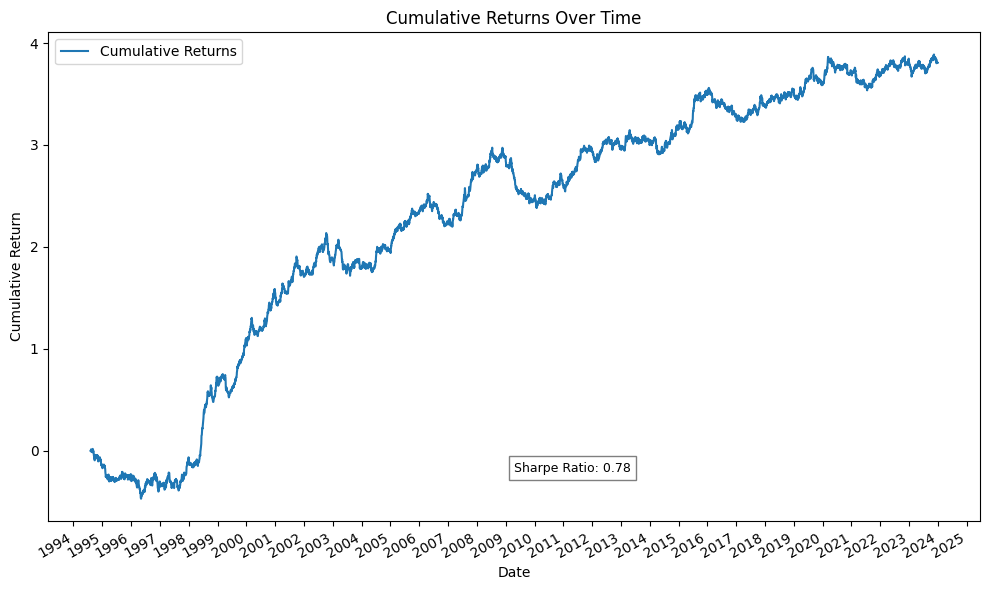

                            OLS Regression Results                            
Dep. Variable:              LS_return   R-squared:                       0.472
Model:                            OLS   Adj. R-squared:                  0.472
Method:                 Least Squares   F-statistic:                     1656.
Date:                Mon, 02 Feb 2026   Prob (F-statistic):               0.00
Time:                        19:07:20   Log-Likelihood:                 25606.
No. Observations:                7403   AIC:                        -5.120e+04
Df Residuals:                    7398   BIC:                        -5.117e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0003   8.86e-05      3.863      0.0

In [170]:
analyze_cumulative_returns(strategy_df=strategy, column_name='LS_return')

In [171]:
# Result: The mktrf coefficient in the factor regression should now be close to zero,
# confirming we have successfully removed systematic market exposure.

In [172]:
# WORST SINGLE DAYS: These reveal tail risks and market stress events
# Notable dates:
# - Nov 9, 2020: COVID vaccine announcement (Pfizer) caused massive rotation
# - Aug 8, 2007: Beginning of the Quant Crisis (many factor strategies crashed)
strategy.nsmallest(5, 'LS_return')

,LS_return
date,
2020-11-09,-0.081271
2022-11-10,-0.058724
1998-01-02,-0.056357
2007-08-08,-0.054591
2009-10-28,-0.042150


In [173]:
# WORST 5-DAY DRAWDOWNS: Captures extended stress periods
# The August 2007 "Quant Quake" stands out - a sudden deleveraging event where
# many quant funds using similar strategies unwound positions simultaneously,
# causing factor strategies to crash. This is a key risk in crowded strategies.
strategy['cum_5d'] = strategy['LS_return'].rolling(5).sum()
strategy['cum_5d'].nsmallest(3)

date
1999-04-19   -0.125845
2007-08-10   -0.112313
1999-04-16   -0.106357
Name: cum_5d, dtype: float64

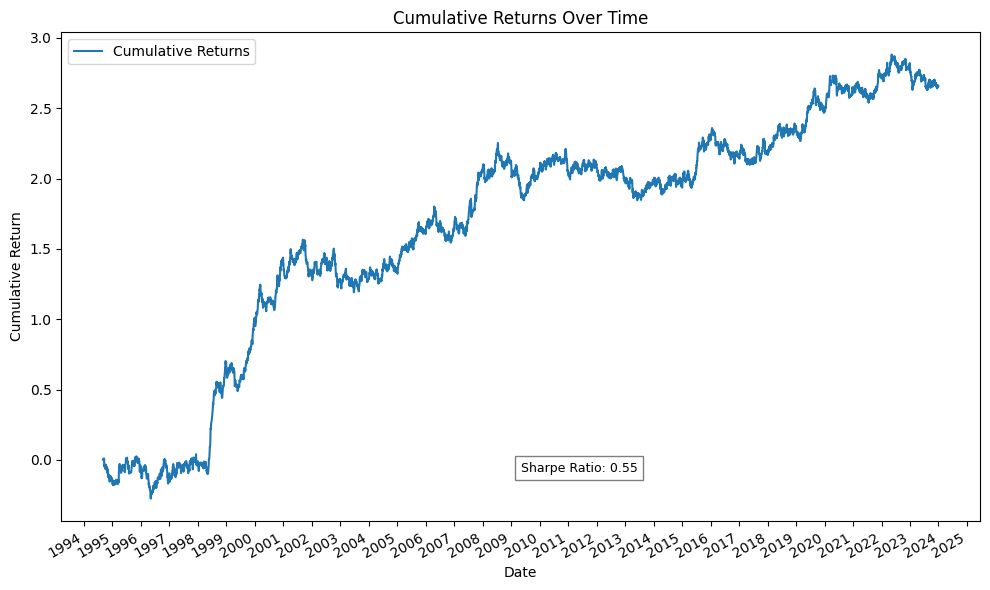

                            OLS Regression Results                            
Dep. Variable:              LS_return   R-squared:                       0.438
Model:                            OLS   Adj. R-squared:                  0.438
Method:                 Least Squares   F-statistic:                     1437.
Date:                Mon, 02 Feb 2026   Prob (F-statistic):               0.00
Time:                        19:07:50   Log-Likelihood:                 25310.
No. Observations:                7383   AIC:                        -5.061e+04
Df Residuals:                    7378   BIC:                        -5.057e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002   9.15e-05      1.736      0.0

In [174]:
# ALTERNATIVE MOMENTUM: 6-month lookback with 3-month skip
# Different parameterization: window=120 days (~6 months), skip=60 days (~3 months)
# This avoids both short-term reversal AND very stale signals

df['mom'] = df.groupby('PERMNO')['RET'].transform(
    lambda x: x.rolling(window=120, min_periods=90).sum().shift(60)
)
strategy = calculate_ls_returns_v2(df=df, sorting_variable='mom', threshold=0.3, Nstocks=1500, ndays=20)
analyze_cumulative_returns(strategy_df=strategy, column_name='LS_return')

## APPENDIX: Alternative Momentum Signals

The academic literature has documented several variations on the basic momentum signal that can improve performance. Below we test four promising alternatives.

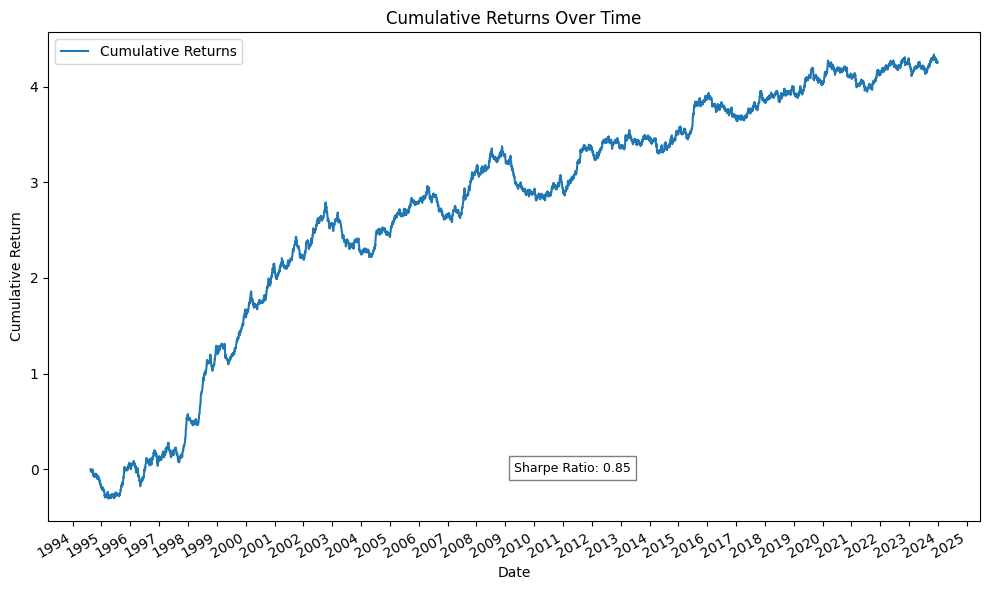

                            OLS Regression Results                            
Dep. Variable:              LS_return   R-squared:                       0.539
Model:                            OLS   Adj. R-squared:                  0.539
Method:                 Least Squares   F-statistic:                     2161.
Date:                Mon, 02 Feb 2026   Prob (F-statistic):               0.00
Time:                        19:08:23   Log-Likelihood:                 25937.
No. Observations:                7397   AIC:                        -5.186e+04
Df Residuals:                    7392   BIC:                        -5.183e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004   8.45e-05      4.843      0.0

In [175]:
# VARIANT 1: SHARPE MOMENTUM (Volatility-Scaled Signal)
# 
# Idea: Divide momentum by volatility to get a "risk-adjusted" signal.
# A stock with +20% return and 40% volatility is less impressive than
# a stock with +15% return and 10% volatility.
#
# This penalizes volatile stocks with lucky streaks and rewards consistent performers.

df['rolling_vol'] = df.groupby('PERMNO')['RET'].transform(
    lambda x: x.rolling(window=231, min_periods=115).std().shift(21)
)
df['sharpe_momentum'] = df['momentum'] / df['rolling_vol']

strategy = calculate_ls_returns_v2(df=df, sorting_variable='sharpe_momentum', threshold=0.3, Nstocks=1500, ndays=20)
analyze_cumulative_returns(strategy_df=strategy, column_name='LS_return')

In [ ]:
def calculate_ls_returns_rank(df, sorting_variable, Nstocks, ndays):
    """
    Long-short strategy with CONTINUOUS rank-based weights.
    
    Instead of discrete +1/-1 positions for top/bottom percentiles,
    uses weight = (rank - 0.5), so:
    - Top ranked stock gets weight +0.5
    - Bottom ranked stock gets weight -0.5
    - Median stock gets weight 0
    
    This is a linear weighting scheme that uses ALL stocks in the universe.
    Turnover is adjusted for leverage changes (as % of nominal).
    
    Convention: Nominal = 2 (like Fama-French factors).
    """
    strategy_df = df.copy()
    
    # Restrict to top N stocks by market cap
    strategy_df = strategy_df[strategy_df['rank'] <= Nstocks]
    strategy_df.dropna(subset=[sorting_variable], inplace=True)

    # Rank stocks by signal within each day (pct_rank: 0=lowest, 1=highest)
    strategy_df['pct_rank'] = strategy_df.groupby('date')[sorting_variable].rank(
        method='first', ascending=True, pct=True
    )
    
    # Center the rank around 0: ranges from -0.5 (worst) to +0.5 (best)
    strategy_df['weight'] = (strategy_df['pct_rank'] - 0.5).clip(-.2,.2)
    
    # Normalize weights to sum to 0 each day (dollar-neutral)
    # and scale so sum of absolute weights = 2 (nominal = 2, like Fama-French)
    strategy_df['weight'] = strategy_df.groupby('date')['weight'].transform(
        lambda x: 2 * x / x.abs().sum()
    )
    
    # Calculate weighted return for each day
    strategy_df['weighted_ret'] = strategy_df['weight'] * strategy_df['RET']
    LS_return = strategy_df.groupby('date')['weighted_ret'].sum()
    
    # Calculate base turnover as % of nominal (divide by 2)
    strategy_df = strategy_df.sort_values(['PERMNO', 'date'])
    strategy_df['weight_change'] = strategy_df.groupby('PERMNO')['weight'].diff().abs()
    base_turnover = strategy_df.groupby('date')['weight_change'].sum() / 2
    
    LS = pd.DataFrame({
        'LS_return': LS_return,
        'turnover': base_turnover
    })
    
    # Apply volatility targeting
    LS['leverage'] = (1 / LS['LS_return'].rolling(window=ndays).std()).shift(1)
    LS['leverage'] = LS['leverage'] / LS['leverage'].std()
    
    # Adjust turnover for leverage (all as % of nominal)
    LS['turnover'] = LS['leverage'] * LS['turnover'] + LS['leverage'].diff().abs()
    
    # Apply leverage to returns
    LS['LS_return'] = LS['leverage'] * LS['LS_return']
    
    return LS[['LS_return', 'turnover']]

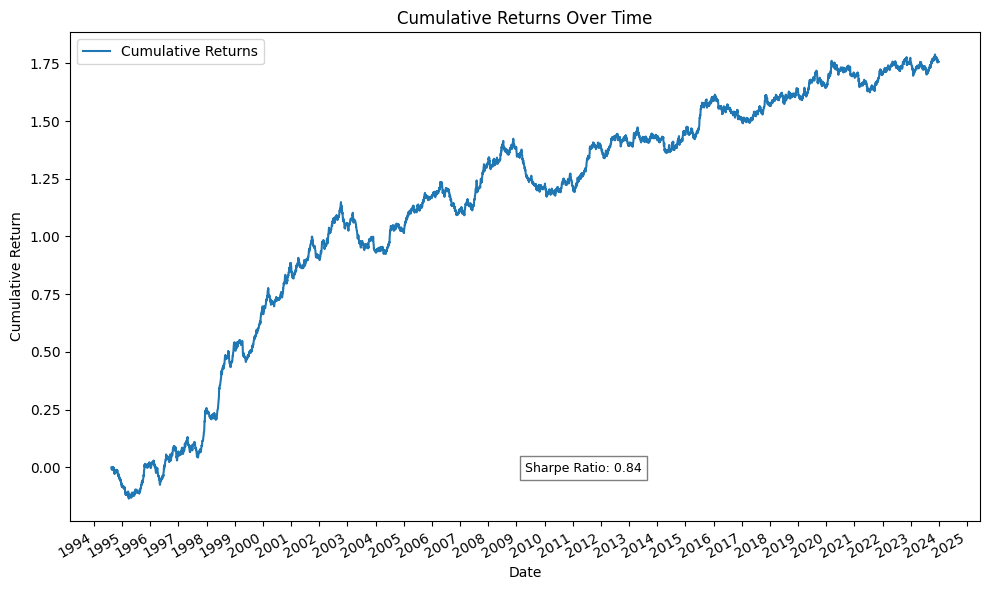

                            OLS Regression Results                            
Dep. Variable:              LS_return   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     2174.
Date:                Mon, 02 Feb 2026   Prob (F-statistic):               0.00
Time:                        19:08:49   Log-Likelihood:                 32404.
No. Observations:                7397   AIC:                        -6.480e+04
Df Residuals:                    7392   BIC:                        -6.476e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0002   3.53e-05      4.742      0.0

In [177]:
# VARIANT: SHARPE MOMENTUM with CONTINUOUS RANK WEIGHTS
#
# Instead of going long top 30% and short bottom 30% with equal weights,
# we use ALL stocks with weights proportional to their rank.
# This creates a smoother signal that uses more information.

strategy = calculate_ls_returns_rank(df=df, sorting_variable='sharpe_momentum', Nstocks=1500, ndays=20)
analyze_cumulative_returns(strategy_df=strategy, column_name='LS_return')

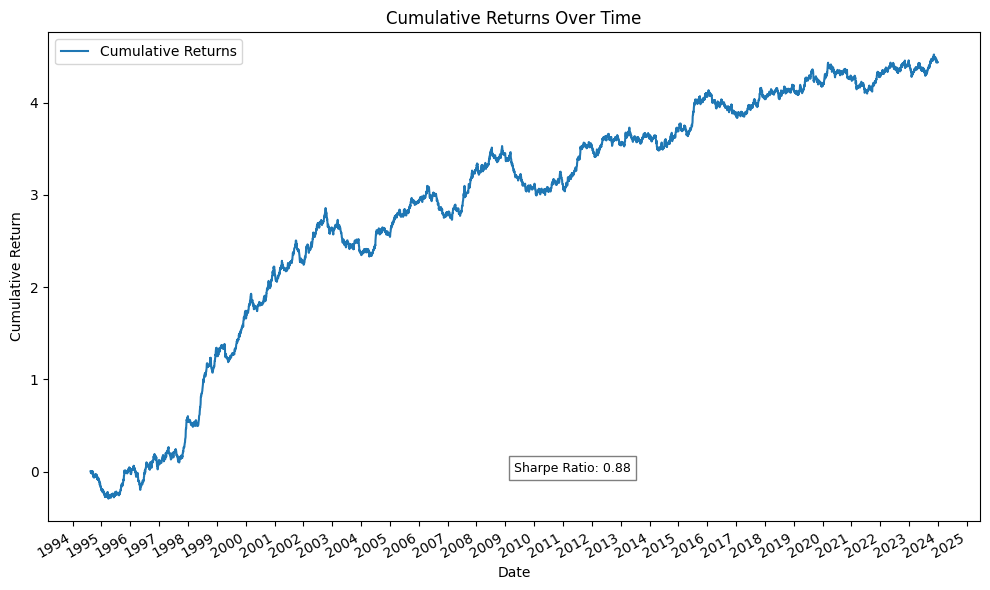

                            OLS Regression Results                            
Dep. Variable:              LS_return   R-squared:                       0.543
Model:                            OLS   Adj. R-squared:                  0.543
Method:                 Least Squares   F-statistic:                     2195.
Date:                Mon, 02 Feb 2026   Prob (F-statistic):               0.00
Time:                        19:09:19   Log-Likelihood:                 25906.
No. Observations:                7397   AIC:                        -5.180e+04
Df Residuals:                    7392   BIC:                        -5.177e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0004   8.49e-05      5.124      0.0

In [178]:
# VARIANT 4: CONTINUOUS MOMENTUM - "Frog in the Pan" (Da, Gurun & Warachka, 2014)
#
# Idea: Momentum built from MANY SMALL GAINS is more persistent than momentum
# from a FEW LARGE JUMPS. Investors underreact more to continuous information
# than to discrete, attention-grabbing events.
#
# Signal = fraction of positive return days over the lookback period
# - High values (many up days) → go long (persistent uptrend)
# - Low values (many down days) → go short (persistent downtrend)

df['positive_days'] = df.groupby('PERMNO')['RET'].transform(
    lambda x: (x > 0).rolling(window=231, min_periods=115).mean().shift(21)
)

# Signed consistency: works for both long AND short legs
# Positive momentum stocks: reward high positive_days
# Negative momentum stocks: penalize with negative score
df['continuous_mom'] = np.where(
    df['momentum'] > 0,
    df['positive_days']*df['sharpe_momentum'],           # Long candidates: many up days is good
    df['positive_days'] - 1        # Short candidates: few up days → negative score
)

strategy = calculate_ls_returns_v2(df=df, sorting_variable='continuous_mom', threshold=0.3, Nstocks=1500, ndays=20)
#strategy = calculate_ls_returns_rank(df=df, sorting_variable='continuous_mom', Nstocks=1500, ndays=20)
analyze_cumulative_returns(strategy_df=strategy, column_name='LS_return')

## Remark: reversal = - short-term momentum

Different lookback periods capture different market phenomena:
- **Short-term (1-4 weeks):** Often shows REVERSAL (losers bounce back)
- **Medium-term (3-12 months):** Classic MOMENTUM (winners keep winning)
- **Long-term (3-5 years):** Mean reversion (long-term reversal)

Below we explore reversal and alternative momentum definitions.

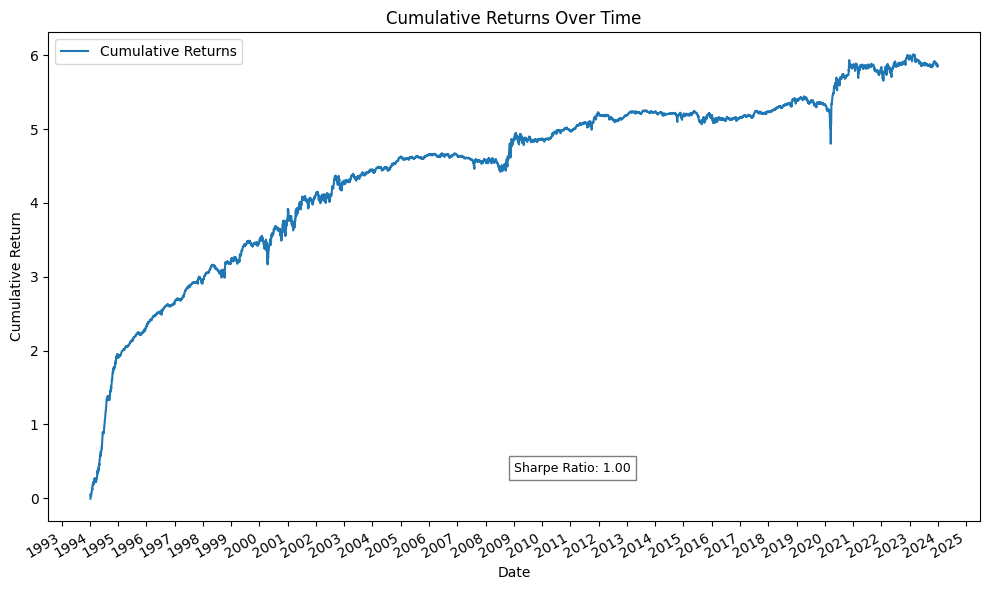

                            OLS Regression Results                            
Dep. Variable:              LS_return   R-squared:                       0.078
Model:                            OLS   Adj. R-squared:                  0.078
Method:                 Least Squares   F-statistic:                     159.9
Date:                Mon, 02 Feb 2026   Prob (F-statistic):          1.54e-131
Time:                        19:09:54   Log-Likelihood:                 22746.
No. Observations:                7547   AIC:                        -4.548e+04
Df Residuals:                    7542   BIC:                        -4.545e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007      0.000      4.954      0.0

In [179]:
# SHORT-TERM REVERSAL STRATEGY
# At very short horizons (1-2 weeks), returns tend to REVERSE: recent losers outperform.
# This is the opposite of momentum - we BUY recent losers and SELL recent winners.
# The negative sign flips the signal to create a "short losers, long winners" position.

df['reversal'] = -df.groupby('PERMNO')['RET'].transform(
    lambda x: x.rolling(window=10, min_periods=5).sum().shift(1)
)
strategy = calculate_ls_returns(df=df, sorting_variable='reversal', threshold=0.2, Nstocks=1500)
analyze_cumulative_returns(strategy_df=strategy, column_name='LS_return')

## Idea 3: Signal Smoothing and Turnover

A key practical consideration for trading strategies is **TURNOVER**: how much do we need to trade to maintain our positions?

High turnover = high transaction costs (commissions, bid-ask spread, market impact)

The REVERSAL signal is particularly prone to high turnover because it reacts quickly to recent price movements. We can reduce turnover by **SMOOTHING** the signal using an exponentially weighted moving average (EWM).

**KEY INSIGHT:** There is a tradeoff between:
- **GROSS SHARPE**: Performance before transaction costs (favors raw signal)
- **TURNOVER**: Trading activity (lower is better for costs)

With transaction costs, there is an OPTIMAL amount of smoothing.

In [181]:
# Compute the raw reversal signal (no smoothing)
# Reversal = negative of past 10-day return (buy losers, sell winners)
df['reversal_raw'] = -df.groupby('PERMNO')['RET'].transform(
    lambda x: x.rolling(window=10, min_periods=5).sum().shift(1)
)

In [182]:
# Apply EWM smoothing with different half-lives
# Higher halflife = more smoothing = lower turnover but potentially lower gross Sharpe
#
# EWM decay: weight of observation k days ago = 0.5^(k/halflife)
# halflife=1: very responsive, close to raw signal
# halflife=20: heavily smoothed, slow to react

halflife_values = [1, 2, 5, 10, 20]  # Days

for hl in halflife_values:
    col_name = f'reversal_hl{hl}'
    df[col_name] = df.groupby('PERMNO')['reversal_raw'].transform(
        lambda x: x.ewm(halflife=hl, min_periods=1).mean()
    )

In [ ]:
# Run strategies for each smoothing level and collect results
results = {}

for hl in halflife_values:
    col_name = f'reversal_hl{hl}'
    strat = calculate_ls_returns(df, col_name, threshold=0.2, Nstocks=1500)
    results[hl] = strat
    
    # Compute statistics
    gross_sharpe = strat['LS_return'].mean() / strat['LS_return'].std() * np.sqrt(252)
    avg_turnover = strat['turnover'].mean()
    print(f"Halflife={hl:2d}: Gross Sharpe = {gross_sharpe:.2f}, Avg Daily Turnover = {avg_turnover:.2%}")

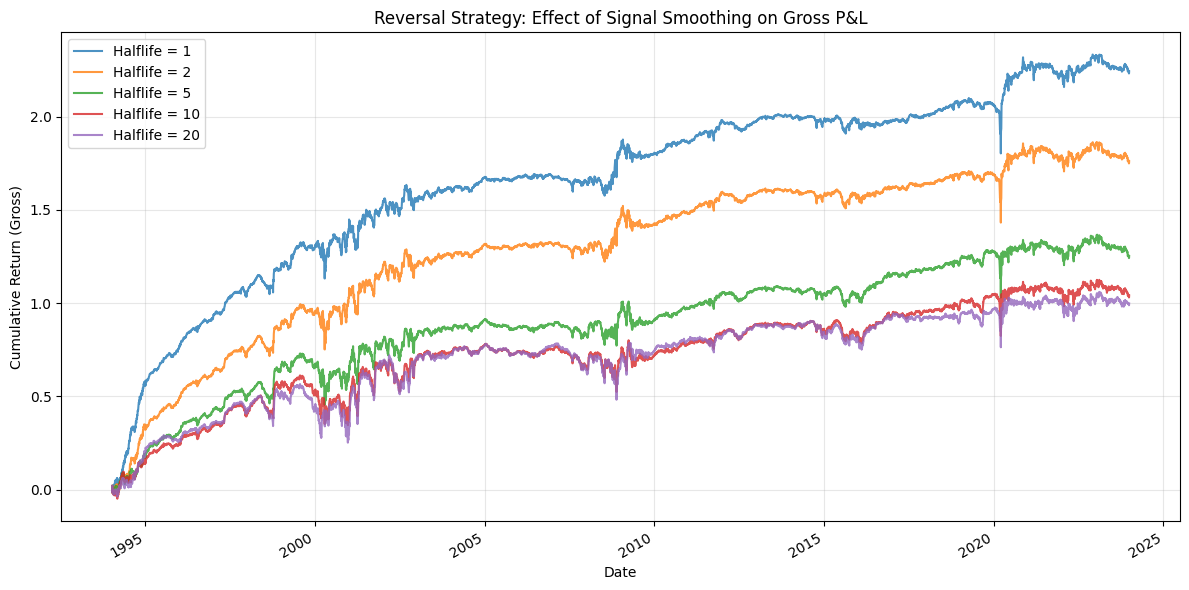

In [184]:
# Plot cumulative P&L for different smoothing levels (GROSS, before transaction costs)
plt.figure(figsize=(12, 6))

for hl in halflife_values:
    cum_pnl = results[hl]['LS_return'].cumsum()
    plt.plot(cum_pnl.index, cum_pnl.values, label=f'Halflife = {hl}', alpha=0.8)

plt.gca().xaxis.set_major_locator(mdates.YearLocator(5))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gcf().autofmt_xdate()
plt.xlabel('Date')
plt.ylabel('Cumulative Return (Gross)')
plt.title('Reversal Strategy: Effect of Signal Smoothing on Gross P&L')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# =============================================================================
# TRANSACTION COSTS AND NET SHARPE
# =============================================================================
#
# Net return = Gross return - TC(turnover)
#
# CONVEX COSTS: TC = c × turnover²
#   - Market impact increases with trade size (price moves against you)
#   - More realistic: trading 10% in one day costs more than 2×(trading 5%)
#   - Creates an INTERIOR OPTIMUM: balance between signal decay and trading costs

# ============================================
# >>> TRANSACTION COST PARAMETER (EDIT HERE)
# ============================================
TC_CONVEX = 0.0030    # 30 bps × turnover² (market impact)
# ============================================

print(f"Transaction cost model: {TC_CONVEX*10000:.0f} bps × turnover²")

# Collect statistics and compute net Sharpe for each smoothing level
stats = []
for hl in halflife_values:
    strat = results[hl]
    gross_sharpe = strat['LS_return'].mean() / strat['LS_return'].std() * np.sqrt(252)
    avg_turnover = strat['turnover'].mean()
    
    # Compute net return with convex transaction costs
    tc_cost = TC_CONVEX * (strat['turnover'] ** 2)
    strat['net_return'] = strat['LS_return'] - tc_cost
    net_sharpe = strat['net_return'].mean() / strat['net_return'].std() * np.sqrt(252)
    
    stats.append({
        'halflife': hl,
        'gross_sharpe': gross_sharpe,
        'avg_turnover': avg_turnover,
        'net_sharpe': net_sharpe
    })

stats_df = pd.DataFrame(stats)
stats_df

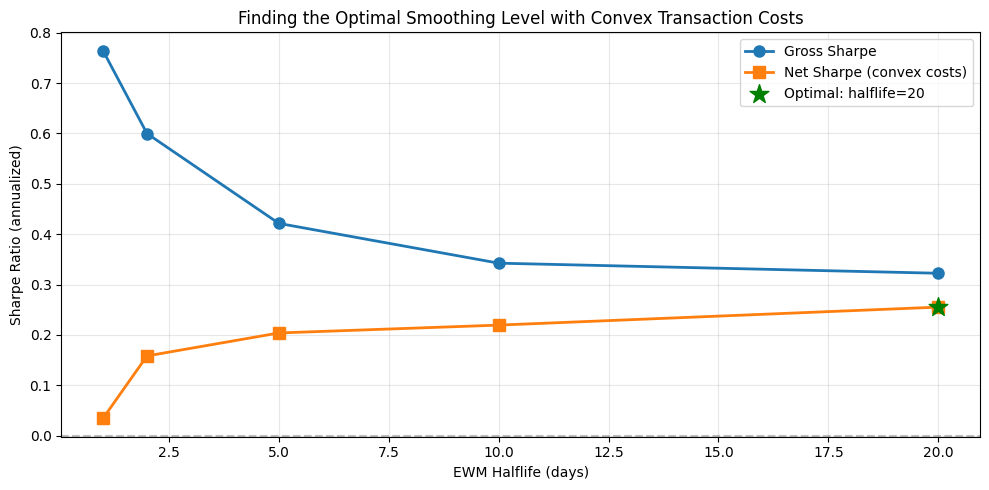


Optimal smoothing: halflife = 20 days
Gross Sharpe at optimal: 0.32
Net Sharpe at optimal:   0.26


In [206]:
# Plot Gross vs Net Sharpe as a function of smoothing
plt.figure(figsize=(10, 5))

plt.plot(stats_df['halflife'], stats_df['gross_sharpe'], 'o-', 
         label='Gross Sharpe', linewidth=2, markersize=8)
plt.plot(stats_df['halflife'], stats_df['net_sharpe'], 's-', 
         label=f'Net Sharpe (convex costs)', linewidth=2, markersize=8)

# Mark the optimal
optimal_idx = stats_df['net_sharpe'].idxmax()
optimal_hl = stats_df.loc[optimal_idx, 'halflife']
optimal_net_sharpe = stats_df.loc[optimal_idx, 'net_sharpe']
plt.scatter([optimal_hl], [optimal_net_sharpe], color='green', s=200, zorder=5, 
            marker='*', label=f'Optimal: halflife={optimal_hl}')

plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('EWM Halflife (days)')
plt.ylabel('Sharpe Ratio (annualized)')
plt.title('Finding the Optimal Smoothing Level with Convex Transaction Costs')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nOptimal smoothing: halflife = {optimal_hl} days")
print(f"Gross Sharpe at optimal: {stats_df.loc[optimal_idx, 'gross_sharpe']:.2f}")
print(f"Net Sharpe at optimal:   {optimal_net_sharpe:.2f}")